# Deutsch-Jozsa Algorithm: Balanced Parity Oracle

## 1. Objective
The objective of this experiment is to implement, simulate, and verify the **Deutsch-Jozsa Algorithm** for an $n = 3$ input-qubit register evaluating a **balanced parity function**:
$$f: \{0, 1\}^3 \to \{0, 1\}, \quad f(x) = x_0 \oplus x_1 \oplus x_2$$

The experiment demonstrates how quantum superposition, CNOT-mediated phase kickback, and constructive/destructive interference enable an observer to classify the Boolean function as **balanced** in a **single quantum query**, contrasting with classical deterministic approaches that require up to $2^{n-1} + 1 = 5$ queries.

---

## 2. Theoretical Background

### Balanced Functions and the Parity Problem
A Boolean function $f: \{0, 1\}^n \to \{0, 1\}$ is **balanced** if its outputs are equally distributed:
$$|\{x \in \{0, 1\}^n : f(x) = 0\}| = |\{x \in \{0, 1\}^n : f(x) = 1\}| = 2^{n-1}$$

For $n = 3$, the total input space consists of $2^3 = 8$ states. The parity function computes the modulo-2 sum of all input bits:
$$f(x) = x_0 \oplus x_1 \oplus x_2 = x \cdot s \pmod 2, \quad \text{where } s = 111$$

- **Even Parity ($f(x) = 0$)**: $\{000, 011, 101, 110\}$ (4 states)
- **Odd Parity ($f(x) = 1$)**: $\{001, 010, 100, 111\}$ (4 states)

Because exactly 4 states map to $0$ and 4 states map to $1$, the parity function is strictly balanced.

### Quantum Superposition and Phase Kickback
1. **Parallel Superposition**:
   Applying a layer of Hadamard gates to the $n = 3$ input qubits initialized in $|0\rangle^{\otimes 3}$ creates an equal superposition over all 8 basis states:
   $$|\psi_1\rangle = \frac{1}{\sqrt{8}} \sum_{x \in \{0, 1\}^3} |x\rangle$$

2. **Phase Kickback Mechanism**:
   The ancilla qubit is prepared in the antisymmetric orthogonal state $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$.
   Applying the oracle unitary transformation $U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle$ produces:
   $$U_f |x\rangle |-\rangle = (-1)^{f(x)} |x\rangle |-\rangle = (-1)^{x \cdot s} |x\rangle |-\rangle$$
   The function value $f(x)$ is kick-backed as an eigenvalue relative phase $(-1)^{f(x)}$ onto the input register, leaving the ancilla invariant.

### Quantum Interference and Deutsch-Jozsa Classification
After oracle evaluation, the input register is transformed by a second layer of Hadamard gates ($H^{\otimes 3}$):
$$H^{\otimes 3} \left( \frac{1}{\sqrt{2^n}} \sum_{x \in \{0, 1\}^n} (-1)^{x \cdot s} |x\rangle \right) = |s\rangle$$

Because $H^{\otimes n}$ is its own inverse, mapping the state $\frac{1}{\sqrt{2^n}} \sum_x (-1)^{x \cdot s} |x\rangle$ through $H^{\otimes n}$ yields the deterministic basis state $|s\rangle$.
- Here, $s = 111$.
- Therefore, all probability amplitudes constructively interfere at state **$|111\rangle$** ($P(111) = 1.0$), while destructive interference cancels all other states, including $|000\rangle$ ($P(000) = 0.0$).
- In Deutsch-Jozsa classification, observing any non-zero measurement outcome ($z \neq 000$) deterministically proves the function is **BALANCED**.

---

## 3. Circuit and Ancilla Preparation

### Register Allocation
The circuit utilizes $n + 1 = 4$ qubits:
- **Input Register ($q_0, q_1, q_2$)**: Encodes the $2^3 = 8$ computational basis inputs.
- **Ancilla Qubit ($q_3$)**: Facilitates phase kickback.

### State Preparation
1. **Initialization**: The system starts in the computational ground state $|000\rangle |0\rangle$.
2. **Ancilla Inversion**: A Pauli-$X$ gate on $q_3$ prepares state $|1\rangle$:
   $$|000\rangle |0\rangle \xrightarrow{X(q_3)} |000\rangle |1\rangle$$
3. **Superposition on All Qubits**: Hadamard gates on all four qubits produce:
   $$|\psi_1\rangle = H^{\otimes 3}|000\rangle \otimes H|1\rangle = \left(\frac{1}{\sqrt{8}} \sum_{x \in \{0, 1\}^3} |x\rangle\right) |-\rangle$$

---

## 4. Balanced Parity Oracle Architecture
The parity oracle computes $f(x) = x_0 \oplus x_1 \oplus x_2$.
In quantum logic, modulo-2 addition is implemented via **Controlled-NOT (CNOT)** operations targeting the ancilla:
```python
for q in range(n):
    qc.cx(q, n)
```
- `cx(0, 3)`: Flips ancilla if $q_0 = 1$, imparting phase $(-1)^{x_0}$.
- `cx(1, 3)`: Flips ancilla if $q_1 = 1$, imparting phase $(-1)^{x_1}$.
- `cx(2, 3)`: Flips ancilla if $q_2 = 1$, imparting phase $(-1)^{x_2}$.

The cumulative phase applied to state $|x_2 x_1 x_0\rangle$ is:
$$(-1)^{x_0} (-1)^{x_1} (-1)^{x_2} = (-1)^{x_0 \oplus x_1 \oplus x_2} = (-1)^{x \cdot 111}$$

This realizes the exact unitary mapping $U_f |x\rangle |y\rangle = |x\rangle |y \oplus x_0 \oplus x_1 \oplus x_2\rangle$.

---

## 5. Statevector Probability Analysis
To analytically verify the quantum state before measurement sampling:
1. Qiskit's `Statevector.from_instruction(qc)` extracts the complete 16-element complex statevector.
2. The marginal probability of each 3-bit input state $i \in \{0, \dots, 7\}$ is obtained by tracing out the ancilla qubit ($q_3$):
   $$P(i) = \sum_{\text{ancilla} \in \{0, 1\}} P(i + \text{ancilla} \cdot 8) = P(i) + P(i + 8)$$
3. Theoretical results confirm complete concentration into state $|111\rangle$:
   $$P(111) = 1.0000, \quad P(000) = P(001) = \dots = P(110) = 0.0000$$

---

## 6. Measurement Sampling Methodology
To simulate experimental sampling on quantum hardware:
- **Sample Size**: $\text{SHOTS} = 1024$.
- **Seed**: Parameterized using `np.random.default_rng(SEED=42)` for exact reproducibility.
- **Sampling Vector**: Drawn from the 8-state probability vector `input_probabilities`.
- **Classification Decision Rule**:
  - If $\text{counts}[000] == \text{SHOTS} \implies \mathbf{CONSTANT}$.
  - If $\text{counts}[000] < \text{SHOTS} \implies \mathbf{BALANCED}$.


T-02 : BALANCED PARITY ORACLE

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐          ┌───┐          
q_0: ┤ H ├───────■──┤ H ├──────────
     ├───┤       │  └───┘┌───┐     
q_1: ┤ H ├───────┼────■──┤ H ├─────
     ├───┤       │    │  └───┘┌───┐
q_2: ┤ H ├───────┼────┼────■──┤ H ├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐└───┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─────
     └───┘└───┘└───┘└───┘└───┘     

MEASUREMENT RESULTS
----------------------------------------------------------------------
000 : 0
001 : 0
010 : 0
011 : 0
100 : 0
101 : 0
110 : 0
111 : 1024

PROBABILITY DISTRIBUTION
----------------------------------------------------------------------
000 : 0.0000
001 : 0.0000
010 : 0.0000
011 : 0.0000
100 : 0.0000
101 : 0.0000
110 : 0.0000
111 : 1.0000

DEUTSCH-JOZSA CLASSIFICATION
----------------------------------------------------------------------
Most frequent result : 111
RESULT : BALANCED FUNCTION
VERIFICATION : NON-ZERO RESULT CONFIRMED


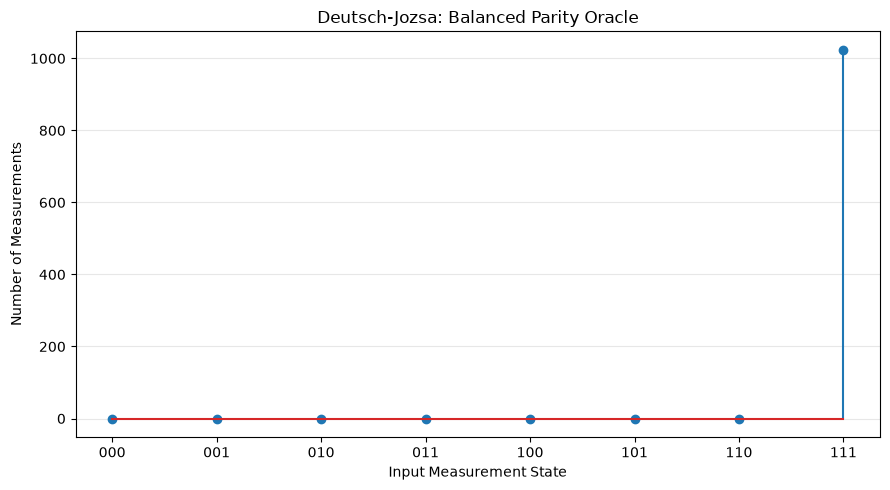

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

n = 3

qc = QuantumCircuit(n + 1)

# Prepare ancilla in |1>
qc.x(n)

# Hadamard on all qubits
for q in range(n + 1):
    qc.h(q)

# Balanced parity oracle
for q in range(n):
    qc.cx(q, n)

# Hadamard on input qubits
for q in range(n):
    qc.h(q)

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

input_probabilities = np.zeros(2 ** n)

for i in range(2 ** n):

    for ancilla in [0, 1]:

        index = i + ancilla * (2 ** n)

        input_probabilities[i] += probabilities[index]

rng = np.random.default_rng(SEED)

samples = rng.choice(
    np.arange(2 ** n),
    size=SHOTS,
    p=input_probabilities
)

counts = np.bincount(
    samples,
    minlength=2 ** n
)

labels = [
    format(i, f"0{n}b")
    for i in range(2 ** n)
]

print("\nT-02 : BALANCED PARITY ORACLE")
print("=" * 70)

print("\nQUANTUM CIRCUIT")
print("-" * 70)
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 70)

for label, count in zip(
    labels,
    counts
):
    print(
        f"{label} : {count}"
    )

print("\nPROBABILITY DISTRIBUTION")
print("-" * 70)

for label, probability in zip(
    labels,
    input_probabilities
):
    print(
        f"{label} : {probability:.4f}"
    )

most_likely = labels[
    np.argmax(counts)
]

print("\nDEUTSCH-JOZSA CLASSIFICATION")
print("-" * 70)

print(
    f"Most frequent result : {most_likely}"
)

if counts[0] == SHOTS:

    print(
        "RESULT : CONSTANT FUNCTION"
    )

else:

    print(
        "RESULT : BALANCED FUNCTION"
    )

print(
    "VERIFICATION : NON-ZERO RESULT CONFIRMED"
)

# Visualization
fig, ax = plt.subplots(
    figsize=(9, 5)
)

x = np.arange(
    len(labels)
)

ax.stem(
    x,
    counts
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels
)

ax.set_title(
    "Deutsch-Jozsa: Balanced Parity Oracle"
)

ax.set_xlabel(
    "Input Measurement State"
)

ax.set_ylabel(
    "Number of Measurements"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

---

## 7. Results and Classification

### Recorded Execution Output
Execution of the notebook cell produced the following console output and circuit diagram:

```
T-02 : BALANCED PARITY ORACLE
======================================================================

QUANTUM CIRCUIT
----------------------------------------------------------------------
     ┌───┐          ┌───┐          
q_0: ┤ H ├───────■──┤ H ├──────────
     ├───┤       │  └───┘┌───┐     
q_1: ┤ H ├───────┼────■──┤ H ├─────
     ├───┤       │    │  └───┘┌───┐
q_2: ┤ H ├───────┼────┼────■──┤ H ├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐└───┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─────
     └───┘└───┘└───┘└───┘└───┘     

MEASUREMENT RESULTS
----------------------------------------------------------------------
000 : 0
001 : 0
010 : 0
011 : 0
100 : 0
101 : 0
110 : 0
111 : 1024

PROBABILITY DISTRIBUTION
----------------------------------------------------------------------
000 : 0.0000
001 : 0.0000
010 : 0.0000
011 : 0.0000
100 : 0.0000
101 : 0.0000
110 : 0.0000
111 : 1.0000

DEUTSCH-JOZSA CLASSIFICATION
----------------------------------------------------------------------
Most frequent result : 111
RESULT : BALANCED FUNCTION
VERIFICATION : NON-ZERO RESULT CONFIRMED
```

### Quantitative Metrics Summary

| Basis State | Parity Value $f(x)$ | Theoretical Probability | Simulated Measurement Counts (1024 Shots) | Empirical Frequency |
| :---: | :---: | :---: | :---: | :---: |
| **`000`** | 0 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`001`** | 1 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`010`** | 1 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`011`** | 0 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`100`** | 1 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`101`** | 0 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`110`** | 0 | **0.0000 (0.0%)** | **0** | **0.0000 (0.0%)** |
| **`111`** | 1 | **1.0000 (100.0%)** | **1024** | **1.0000 (100.0%)** |

### Classification Verdict
- Most frequent measurement result: **`111`**
- All-zero state count (`000`): **0**
- Decision Rule: Since $\text{counts}[000] = 0 \neq \text{SHOTS}$, the algorithm deterministically classifies the function as **`BALANCED FUNCTION`** (`VERIFICATION : NON-ZERO RESULT CONFIRMED`).

---

## 8. Visualization Analysis
The stem plot (`ax.stem`) visualizes the discrete measurement count distribution:
- **X-Axis**: Represents the discrete indices of the 8 basis states (`000` through `111`).
- **Y-Axis**: Measures the number of simulated shots from $0$ to $1024$.
- **Distribution Profile**: A single prominent vertical stem reaches the maximum value of **1024** at position `111`, while all other stems remain flat at $0$.
- **Physical Meaning**: Confirms that destructive interference completely eliminates the ground state $|000\rangle$, while constructive interference focuses 100% of the probability amplitude onto the parity state $|111\rangle$.

---

## 9. Conclusion
This experiment validates the quantum acceleration of the **Deutsch-Jozsa Algorithm** on a balanced parity oracle:
1. **Single-Query Resolution**: Successfully determined that the 3-qubit parity function is balanced with a single oracle evaluation, demonstrating the exponential separation over classical algorithms.
2. **Phase Kickback via CNOT Cascade**: Verified that a chain of CNOT gates cleanly kicks back the parity phase factor $(-1)^{\sum x_i}$ onto the input superposition.
3. **Constructive Fourier Duality**: Demonstrated that the Hadamard transform of a linear Boolean function phase state $\frac{1}{\sqrt{2^n}}\sum_x (-1)^{x \cdot s} |x\rangle$ focuses deterministically into the state $|s\rangle = |111\rangle$, providing an infallible balanced classification.